In [16]:
!python -m pip install numpy matplotlib
!python -m pip install gymnasium==0.29.1
!python -m pip install minigrid
!python -m pip install torch
!python -m pip install gym_minigrid

In [17]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
import torch.optim as optim
from minigrid.wrappers import FullyObsWrapper
from collections import deque, namedtuple
from gymnasium.core import ObservationWrapper
from gymnasium import spaces
from gym_minigrid.envs.empty import EmptyEnv
from gymnasium.wrappers import TimeLimit
import copy

In [18]:
# Set seeds for reproducibility
def set_random_seeds(seed=68):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

In [19]:
# Check for GPU and set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [20]:
# Define environment wrappers
class BasicActionWrapper(gym.Wrapper):
    """Restricts the action space to just: 0: turn left, 1: turn right, 2: move forward"""
    def __init__(self, env):
        super().__init__(env)
        self.action_space = spaces.Discrete(3)

class StateToCoordinatesWrapper(ObservationWrapper):
    """Converts complex observations to simple (x, y, direction) coordinates"""
    def __init__(self, env):
        super().__init__(env)
        grid_size = env.unwrapped.width
        total_cells = grid_size * grid_size
        available_cells = total_cells - grid_size # Account for walls
        total_states = 4 * available_cells # 4 possible directions

        self.observation_space = spaces.Discrete(total_states)

    def observation(self, obs):
        agent_pos = self.env.unwrapped.agent_pos
        agent_pos = (int(agent_pos[0]), int(agent_pos[1]))
        agent_dir = self.env.unwrapped.agent_dir
        return (*agent_pos, agent_dir)

class BinaryRewardWrapper(gym.Wrapper):
    """1.0 for success, -1.0 for *any* end (fail or timeout), 0.0 otherwise."""
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated

        if terminated and reward > 0:
            r = 1.0
        elif done:
            r = -1.0
        else:
            r = 0.0

        return obs, r, terminated, truncated, info

def create_gridworld_env(interior_size=6, max_steps=50, use_coordinates=True):
    """
    interior_size = number of free cells per side
    actual_width  = interior_size + 2 (for the surrounding walls)
    """
    actual_width = interior_size + 2

    env = EmptyEnv(
        size=actual_width,
        render_mode='rgb_array'
    )

    env = TimeLimit(env, max_episode_steps=max_steps)

    env = BasicActionWrapper(env)
    env = BinaryRewardWrapper(env)
    if use_coordinates:
        env = StateToCoordinatesWrapper(env)
    else:
        env = FullyObsWrapper(env)

    return env

In [21]:
# Utility functions for state conversion
def coordinates_to_state_index(x, y, direction, grid_size):
    """Convert position and direction coordinates to a unique state index."""
    return direction + 4 * (y * grid_size + x)

def state_index_to_coordinates(state_idx, grid_size):
    """Convert state index back to (x, y, direction) coordinates"""
    direction = state_idx % 4
    xy_idx = state_idx // 4
    y = xy_idx // grid_size
    x = xy_idx % grid_size
    return (x, y, direction)

In [22]:
# Visualize the environment
def visualize_environment(env, title="Environment Visualization"):
    """Visualize the MiniGrid environment"""
    env.reset()
    img = env.render()
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()
    return img

In [23]:

# EXPLORATION ALGORITHMS


class EMEAgent:
    """
    Implementation of the Effective Metric-based Exploration-bonus (EME) agent
    Key features:
    1. Uses ensemble of reward models to estimate prediction variance
    2. Computes EME metric for state discrepancy evaluation
    3. Uses the metric with a diversity-enhanced scaling factor for exploration
    """
    def __init__(self, state_dim, action_dim, gamma=0.99, learning_rate=0.1,
                 ensemble_size=5, bonus_scale=0.1, max_scaling=5.0):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.learning_rate = learning_rate
        self.bonus_scale = bonus_scale
        self.max_scaling   = max_scaling
        self.ensemble_size = ensemble_size

        # Q-values
        self.q_table = np.zeros((state_dim, action_dim))

        # Ensemble of reward predictors
        self.reward_predictors = [np.zeros((state_dim, action_dim))
                               for _ in range(ensemble_size)]

        # State representation
        self.state_visits = np.zeros(state_dim)

        # Metrics
        self.episode_rewards = []
        self.exploration_bonuses = []
        self.episode_steps = []
        self.success_rates = []

    def get_state_distance(self, state1, state2, grid_size):
      """
      Calculate state distance based on EME metric that is closely aligned with the paper:
      dE(si, sj) = |Eai∼πrai_si - Eaj∼πraj_sj| + γE[dE(s'i, s'j)] + γDKL(π(·|si)||π(·|sj))
      """
      x1, y1, d1 = state_index_to_coordinates(state1, grid_size)
      x2, y2, d2 = state_index_to_coordinates(state2, grid_size)

      # Component 1: Expected reward difference (approximated by predicted rewards)
      reward_diff = abs(np.mean([predictor[state1].max() for predictor in self.reward_predictors]) -
                        np.mean([predictor[state2].max() for predictor in self.reward_predictors]))

      # Component 2: Spatial distance (as proxy for transition model distance)
      pos_dist = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

      # Component 3: Policy divergence (approximated by direction difference)
      # For tabular case, we can approximate KL divergence using action distribution
      best_action1 = np.argmax(self.q_table[state1])
      best_action2 = np.argmax(self.q_table[state2])
      policy_div = 0.5 if best_action1 != best_action2 else 0.0

      # Combine all components with weights
      distance = 0.4 * reward_diff + 0.4 * pos_dist + 0.2 * policy_div

      return distance

    def compute_reward_variance(self, state, action):
      """
      Compute variance across reward model ensemble predictions
      Closely aligned with equation 5 in the paper
      """
      if self.state_visits[state] < 1:  # For unvisited states, return max variance
          return 5.0

      # Get predictions from all models for this state-action
      predictions = [predictor[state, action] for predictor in self.reward_predictors]

      # Calculate mean prediction
      mean_pred = np.mean(predictions)

      # Calculate variance
      variance = np.mean([(pred - mean_pred)**2 for pred in predictions])

      return variance

    def compute_exploration_bonus(self, state, next_state, action, grid_size):
      """
      Calculate the EME exploration bonus aligned with equation 2 in the paper:
      bt+1 = dE(st, st+1) * min{max{ζ(rst), 1}, M}
      """
      # State distance
      distance = self.get_state_distance(state, next_state, grid_size)

      # Reward variance (uncertainty)
      variance = self.compute_reward_variance(state, action)

      # Apply scaling factor bounds as in the paper
      scaling_factor = min(max(variance, 1.0), self.max_scaling)



      visit_decay = 1.0 / np.sqrt(self.state_visits[state] + 1)
      return self.bonus_scale * distance * scaling_factor * visit_decay



    def update_reward_predictors(self, state, action, reward):
      """Update the ensemble of reward predictors with diversity preservation"""
      # Add small noise to maintain diversity between predictors
      for i in range(self.ensemble_size):
          # Each predictor gets slightly different training data
          if random.random() < 0.8:  # 80% chance of updating each predictor
              # Add small noise to reward to increase diversity
              noisy_reward = reward + np.random.normal(0, 0.05)

              # Update predictor with learning rate decay
              lr = self.learning_rate / (1 + 0.1 * self.state_visits[state])
              self.reward_predictors[i][state, action] += lr * (noisy_reward -
                                                              self.reward_predictors[i][state, action])

    def compute_policy_divergence(self, state1, state2, temperature=0.1):
        """
        Compute KL divergence between policies at two states
        Using softmax of Q-values to represent policies
        """
        # Get Q-values for both states
        q_values1 = self.q_table[state1]
        q_values2 = self.q_table[state2]

        # Convert to probabilities using softmax
        def softmax(x, temp):
            exp_x = np.exp(x / temp)
            return exp_x / np.sum(exp_x)

        p1 = softmax(q_values1, temperature)
        p2 = softmax(q_values2, temperature)

        # Compute KL divergence: KL(p1||p2) = sum(p1 * log(p1/p2))
        # Add small epsilon to avoid division by zero
        epsilon = 1e-10
        kl = np.sum(p1 * np.log((p1 + epsilon) / (p2 + epsilon)))

        return kl

    def select_action(self, state, epsilon=0.1):
        """Select action using epsilon-greedy policy"""
        if random.random() < epsilon:
            return random.randrange(self.action_dim)
        else:
            return np.argmax(self.q_table[state])

    def update(self, state, action, reward, next_state, done, exploration_bonus, grid_size):
        """Update Q-values with exploration bonus"""
        # Update state visits
        self.state_visits[state] += 1

        # Update reward predictors
        self.update_reward_predictors(state, action, reward)

        # Calculate combined reward
        combined_reward = reward + exploration_bonus

        # Standard Q-learning update
        best_next_action = np.argmax(self.q_table[next_state])
        td_target = combined_reward + (1 - done) * self.gamma * self.q_table[next_state, best_next_action]
        td_error = td_target - self.q_table[state, action]
        self.q_table[state, action] += self.learning_rate * td_error

    def train(self, env, num_episodes=100, max_steps=100,
          epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.95):
      """
      Train the EME agent with more detailed tracking of components
      to better align with the original paper methodology
      """
      epsilons = []
      epsilon = epsilon_start
      grid_size = int(np.sqrt(self.state_dim/4))

      # Track more components for analysis
      self.distance_components = {
          'reward_diff': [],
          'spatial_dist': [],
          'policy_div': [],
          'variances': []
      }

      for episode in range(num_episodes):
          state_tuple, _ = env.reset()
          x, y, direction = state_tuple
          state = coordinates_to_state_index(x-1, y-1, direction, grid_size)

          episode_reward = 0
          exploration_bonus_sum = 0
          steps = 0
          episode_components = []

          for step in range(max_steps):
              # Select action using epsilon-greedy policy
              action = self.select_action(state, epsilon)

              # Take action
              next_state_tuple, reward, terminated, truncated, _ = env.step(action)
              nx, ny, ndirection = next_state_tuple
              next_state = coordinates_to_state_index(nx-1, ny-1, ndirection, grid_size)
              done = terminated or truncated

              # Calculate individual distance components for analysis
              x1, y1, d1 = state_index_to_coordinates(state, grid_size)
              x2, y2, d2 = state_index_to_coordinates(next_state, grid_size)

              # Component 1: Expected reward difference
              reward_diff = abs(np.mean([predictor[state].max() if len(predictor[state]) > 0 else 0
                                      for predictor in self.reward_predictors]) -
                              np.mean([predictor[next_state].max() if len(predictor[next_state]) > 0 else 0
                                      for predictor in self.reward_predictors]))

              # Component 2: Spatial distance
              spatial_dist = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

              # Component 3: Policy divergence
              policy_div = self.compute_policy_divergence(state, next_state)

              # Get reward variance for scaling
              variance = self.compute_reward_variance(state, action)

              # Store components for analysis
              episode_components.append((reward_diff, spatial_dist, policy_div, variance))

              # Compute exploration bonus using these components
              exploration_bonus = self.compute_exploration_bonus(state, next_state, action, grid_size)
              exploration_bonus_sum += exploration_bonus

              # Update Q-values with the combined reward (external + intrinsic)
              combined_reward = reward + exploration_bonus
              self.update(state, action, reward, next_state, done, exploration_bonus, grid_size)

              # Update state and counters
              state = next_state
              episode_reward += reward
              steps += 1

              if done:
                  break

          # Decay epsilon
          epsilon = max(epsilon_end, epsilon * epsilon_decay)
          epsilons.append(epsilon)

          # Record metrics
          self.episode_rewards.append(episode_reward)
          self.exploration_bonuses.append(exploration_bonus_sum / steps if steps > 0 else 0)
          self.episode_steps.append(steps)
          self.success_rates.append(1 if episode_reward > 0 else 0)

          # Record component averages for analysis
          if episode_components:
              avg_reward_diff = np.mean([c[0] for c in episode_components])
              avg_spatial_dist = np.mean([c[1] for c in episode_components])
              avg_policy_div = np.mean([c[2] for c in episode_components])
              avg_variance = np.mean([c[3] for c in episode_components])

              self.distance_components['reward_diff'].append(avg_reward_diff)
              self.distance_components['spatial_dist'].append(avg_spatial_dist)
              self.distance_components['policy_div'].append(avg_policy_div)
              self.distance_components['variances'].append(avg_variance)

          # Log progress every 10 episodes
          if (episode + 1) % 10 == 0:
              avg_reward = np.mean(self.episode_rewards[-10:])
              avg_steps = np.mean(self.episode_steps[-10:])
              avg_bonus = np.mean(self.exploration_bonuses[-10:])
              avg_success = np.mean(self.success_rates[-10:])
              print(f"Episode {episode+1}/{num_episodes} | Avg Reward: {avg_reward:.2f} | "
                    f"Avg Steps: {avg_steps:.2f} | Avg Bonus: {avg_bonus:.4f} | "
                    f"Success Rate: {avg_success:.2f} | Epsilon: {epsilon:.4f}")

              # Also log the average components if we have them
              if 'reward_diff' in self.distance_components and len(self.distance_components['reward_diff']) >= 10:
                  avg_reward_diff = np.mean(self.distance_components['reward_diff'][-10:])
                  avg_spatial_dist = np.mean(self.distance_components['spatial_dist'][-10:])
                  avg_policy_div = np.mean(self.distance_components['policy_div'][-10:])
                  avg_variance = np.mean(self.distance_components['variances'][-10:])

                  print(f"  Components: Reward Diff: {avg_reward_diff:.4f} | Spatial: {avg_spatial_dist:.4f} | "
                        f"Policy: {avg_policy_div:.4f} | Variance: {avg_variance:.4f}")

      return {
          'rewards': self.episode_rewards,
          'exploration_bonuses': self.exploration_bonuses,
          'steps': self.episode_steps,
          'success_rates': self.success_rates,
          'epsilons': epsilons,
          'distance_components': self.distance_components
      }

class QEpsilonGreedyAgent:
    """Standard Q-Learning agent with epsilon-greedy exploration"""
    def __init__(self, state_dim, action_dim, gamma=0.99, learning_rate=0.1):
        self.q_table = np.zeros((state_dim, action_dim))
        self.gamma = gamma
        self.learning_rate = learning_rate
        self.episode_rewards = []
        self.episode_steps = []
        self.success_rates = []

    def select_action(self, state, epsilon=0.1):
        if random.random() < epsilon:
            return random.randrange(self.q_table.shape[1])
        else:
            return np.argmax(self.q_table[state])

    def update(self, state, action, reward, next_state, done):
        """Q-Learning update rule"""
        best_next_action = np.argmax(self.q_table[next_state])
        td_target = reward + (1 - done) * self.gamma * self.q_table[next_state, best_next_action]
        td_error = td_target - self.q_table[state, action]
        self.q_table[state, action] += self.learning_rate * td_error

    def train(self, env, num_episodes=100, max_steps=100,
              epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.95):
        """Train using epsilon-greedy exploration"""
        epsilons = []
        epsilon = epsilon_start
        grid_size = int(np.sqrt(self.q_table.shape[0]/4))

        for episode in range(num_episodes):
            state_tuple, _ = env.reset()
            x, y, direction = state_tuple
            state = coordinates_to_state_index(x-1, y-1, direction, grid_size)

            episode_reward = 0
            steps = 0

            for step in range(max_steps):
                # Select action
                action = self.select_action(state, epsilon)

                # Take action
                next_state_tuple, reward, terminated, truncated, _ = env.step(action)
                nx, ny, ndirection = next_state_tuple
                next_state = coordinates_to_state_index(nx-1, ny-1, ndirection, grid_size)
                done = terminated or truncated

                # Update Q-table
                self.update(state, action, reward, next_state, done)

                state = next_state
                episode_reward += reward
                steps += 1

                if done:
                    break

            # Decay epsilon
            epsilon = max(epsilon_end, epsilon * epsilon_decay)
            epsilons.append(epsilon)

            # Record metrics
            self.episode_rewards.append(episode_reward)
            self.episode_steps.append(steps)
            self.success_rates.append(1 if episode_reward > 0 else 0)

            # Log progress every 10 episodes
            if (episode + 1) % 10 == 0:
                avg_reward = np.mean(self.episode_rewards[-10:])
                avg_steps = np.mean(self.episode_steps[-10:])
                avg_success = np.mean(self.success_rates[-10:])
                print(f"Episode {episode+1}/{num_episodes} | Avg Reward: {avg_reward:.2f} | "
                      f"Avg Steps: {avg_steps:.2f} | Success Rate: {avg_success:.2f} | Epsilon: {epsilon:.4f}")

        return {
            'rewards': self.episode_rewards,
            'steps': self.episode_steps,
            'success_rates': self.success_rates,
            'epsilons': epsilons
        }

In [24]:

# VISUALIZATION FUNCTIONS



def visualize_trajectory(env, agent, grid_size, agent_type="EME", seed=123):
    """Visualize the agent's trajectory"""
    # Reset environment with fixed seed for reproducibility
    state_tuple, _ = env.reset(seed=seed)
    x, y, direction = state_tuple
    state = coordinates_to_state_index(x-1, y-1, direction, grid_size)

    # Prepare grid
    grid = np.zeros((grid_size, grid_size))
    grid[grid_size-1, grid_size-1] = 1  # Goal location

    # Record path
    path = [(x-1, y-1)]
    done = False

    max_steps = 50
    step = 0

    # Run until done or max steps
    while not done and step < max_steps:
        # Choose action
        action = agent.select_action(state, epsilon=0.05)

        # Take step
        next_state_tuple, reward, terminated, truncated, _ = env.step(action)
        nx, ny, ndirection = next_state_tuple
        next_state = coordinates_to_state_index(nx-1, ny-1, ndirection, grid_size)

        # Update state
        state = next_state
        path.append((nx-1, ny-1))
        step += 1

        # Check if done
        done = terminated or truncated

    # Create figure
    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot grid
    ax.imshow(grid, cmap='Greens', alpha=0.3)

    # Plot path
    path = np.array(path)
    ax.plot(path[:, 0], path[:, 1], 'r-o', linewidth=2, markersize=8)

    # Highlight start and end
    ax.plot(path[0, 0], path[0, 1], 'bo', markersize=12, label='Start')
    ax.plot(path[-1, 0], path[-1, 1], 'go', markersize=12, label='End')

    # Add goal indicator
    ax.text(grid_size-1, grid_size-1, 'G', color='darkgreen', fontsize=20, ha='center', va='center')

    # Customize plot
    ax.set_xlim(-0.5, grid_size-0.5)
    ax.set_ylim(-0.5, grid_size-0.5)
    ax.set_xticks(np.arange(grid_size))
    ax.set_yticks(np.arange(grid_size))
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_title(f"{agent_type} Agent Trajectory")
    ax.legend()

    return fig

def visualize_learning_progress(eme_results, q_results, window_size=10):
    """Visualize learning progress metrics"""
    # Smooth function
    def smooth(data, window=window_size):
        kernel = np.ones(window) / window
        return np.convolve(data, kernel, mode='valid')

    # Create figure with 2x2 subplots
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    # Episode length plot
    axs[0, 0].plot(smooth(eme_results['steps']), label='EME')
    axs[0, 0].plot(smooth(q_results['steps']), label='ε-greedy')
    axs[0, 0].set_xlabel('Episode')
    axs[0, 0].set_ylabel('Steps (smoothed)')
    axs[0, 0].set_title('Episode Length')
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # Reward plot
    axs[0, 1].plot(smooth(eme_results['rewards']), label='EME')
    axs[0, 1].plot(smooth(q_results['rewards']), label='ε-greedy')
    axs[0, 1].set_xlabel('Episode')
    axs[0, 1].set_ylabel('Reward (smoothed)')
    axs[0, 1].set_title('Episode Reward')
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # Success rate plot
    axs[1, 0].plot(smooth(eme_results['success_rates']), label='EME')
    axs[1, 0].plot(smooth(q_results['success_rates']), label='ε-greedy')
    axs[1, 0].set_xlabel('Episode')
    axs[1, 0].set_ylabel('Success Rate (smoothed)')
    axs[1, 0].set_title('Goal Reaching Success Rate')
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    # Exploration bonus plot
    axs[1, 1].plot(smooth(eme_results['exploration_bonuses']), label='EME Exploration Bonus')
    axs[1, 1].set_xlabel('Episode')
    axs[1, 1].set_ylabel('Exploration Bonus (smoothed)')
    axs[1, 1].set_title('EME Intrinsic Reward')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.suptitle('Learning Progress Comparison', fontsize=16)
    plt.subplots_adjust(top=0.92)

    return fig

In [25]:

# MAIN EXPERIMENT FUNCTION


def run_exploration_comparison(grid_size=4, num_episodes=200):
    """
    grid_size    = number of free cells per side (interior)
    total_size   = grid_size + 2 (full world size, including border walls)

    """
    set_random_seeds(68)
    total_size = grid_size + 2

    env = create_gridworld_env(
        interior_size=grid_size,
        max_steps=100,
        use_coordinates=True
    )

    obs, _ = env.reset()
    full_img = env.render()                       # (total_size × total_size) image
    tile = full_img.shape[0] // total_size        # pixels per cell
    interior_img = full_img[tile:-tile, tile:-tile]

    plt.figure(figsize=(6, 6))
    plt.imshow(interior_img)
    plt.title(f"Interior: {grid_size}×{grid_size} free cells\n"
              f"(full world {total_size}×{total_size})")
    plt.axis('off')
    plt.show()

    state_dim  = grid_size * grid_size * 4  # x, y, 4 directions
    action_dim = 3  # left, right, forward

    print(f"\nTraining EME agent on {grid_size}×{grid_size} interior...")
    eme_agent = EMEAgent(
        state_dim=state_dim,
        action_dim=action_dim,
        gamma=0.99,
        learning_rate=0.1,
        ensemble_size=5,
        bonus_scale=0.2
    )
    eme_results = eme_agent.train(
        env=env,
        num_episodes=num_episodes,
        max_steps=100,
        epsilon_start=1.0,
        epsilon_end=0.1,
        epsilon_decay=0.99
    )

    print(f"\nTraining ε-greedy Q-learning on {grid_size}×{grid_size} interior...")
    q_agent = QEpsilonGreedyAgent(
        state_dim=state_dim,
        action_dim=action_dim,
        gamma=0.99,
        learning_rate=0.1
    )
    q_results = q_agent.train(
        env=env,
        num_episodes=num_episodes,
        max_steps=100,
        epsilon_start=1.0,
        epsilon_end=0.1,
        epsilon_decay=0.99
    )

    print("\nGenerating learning progress visualization...")
    fig = visualize_learning_progress(eme_results, q_results)
    plt.show()



    print("\nTrajectory (EME):")
    fig4 = visualize_trajectory(env, eme_agent, grid_size, "EME")
    plt.show()

    print("\nTrajectory (ε-greedy):")
    fig5 = visualize_trajectory(env, q_agent, grid_size, "Q-Learning")
    plt.show()

    print("\nPerformance Summary (last 20 episodes):")
    print(f" EME   Success Rate: {np.mean(eme_results['success_rates'][-20:]):.4f}")
    print(f" ε-greedy Success Rate: {np.mean(q_results['success_rates'][-20:]):.4f}")
    print(f" EME   Avg Steps:      {np.mean(eme_results['steps'][-20:]):.2f}")
    print(f" ε-greedy Avg Steps:      {np.mean(q_results['steps'][-20:]):.2f}")
    print(f" EME   Avg Reward:     {np.mean(eme_results['rewards'][-20:]):.2f}")
    print(f" ε-greedy Avg Reward:     {np.mean(q_results['rewards'][-20:]):.2f}")

    return eme_agent, q_agent, eme_results, q_results

In [31]:
import pandas as pd
from IPython.display import display

In [32]:
# Experiment with increasing difficulty
def run_increased_difficulty_experiments():
    """Run experiments with increasing environment sizes to test scalability"""
    set_random_seeds(68)
    results = {}
    grid_sizes = [4, 6, 8]  # Increasing difficulty
    episodes = [400, 600, 800]  # More episodes for harder environments

    for size, eps in zip(grid_sizes, episodes):
        print(f"\n\nRunning experiment with grid size {size} ")
        eme_agent, q_agent, eme_results, q_results = run_exploration_comparison(
            grid_size=size,
            num_episodes=eps
        )

        results[size] = {
            'eme': eme_results,
            'q': q_results
        }

    # Compare success rates across difficulties
    plt.figure(figsize=(10, 6))
    for size in grid_sizes:
        plt.plot([np.mean(results[size]['eme']['success_rates'][i:i+20])
                 for i in range(0, len(results[size]['eme']['success_rates'])-20, 20)],
                 label=f'EME (size={size})')
        plt.plot([np.mean(results[size]['q']['success_rates'][i:i+20])
                 for i in range(0, len(results[size]['q']['success_rates'])-20, 20)],
                 linestyle='--',
                 label=f'ε-greedy (size={size})')

    plt.xlabel('Training Progress (20-episode windows)')
    plt.ylabel('Success Rate')
    plt.title('Learning Success Across Different Environment Sizes')
    plt.legend()
    plt.grid(True)
    plt.savefig('success_across_difficulties.png', dpi=300, bbox_inches='tight')
    plt.show()

      # Collect summary metrics
    summary_data = {
    "Grid Size": [],
    "EME Success Rate": [],
    "ε-greedy Success Rate": [],
    "EME Avg Steps": [],
    "ε-greedy Avg Steps": [],
    "EME Avg Reward": [],
    "ε-greedy Avg Reward": []
    }

    for size in grid_sizes:
        eme = results[size]['eme']
        q = results[size]['q']

        summary_data["Grid Size"].append(f"{size}x{size}")
        summary_data["EME Success Rate"].append(np.mean(eme['success_rates'][-20:]))
        summary_data["ε-greedy Success Rate"].append(np.mean(q['success_rates'][-20:]))
        summary_data["EME Avg Steps"].append(np.mean(eme['steps'][-20:]))
        summary_data["ε-greedy Avg Steps"].append(np.mean(q['steps'][-20:]))
        summary_data["EME Avg Reward"].append(np.mean(eme['rewards'][-20:]))
        summary_data["ε-greedy Avg Reward"].append(np.mean(q['rewards'][-20:]))

    # Convert to DataFrame and display
    summary_df = pd.DataFrame(summary_data)
    print("\nPerformance Summary Table (Last 20 Episodes):")
    display(summary_df)

    return results

In [27]:
# Create a function to experiment with different ensemble sizes
def experiment_with_ensemble_sizes(grid_size=4, max_episodes=100):
    """Experiment with different ensemble sizes and analyze their impact"""
    # Set random seed for reproducibility
    set_random_seeds(68)

    # Create environment
    env = create_gridworld_env(interior_size=grid_size, max_steps=100, use_coordinates=True)

    # State and action dimensions
    state_dim = grid_size * grid_size * 4  # x, y, 4 directions
    action_dim = 3  # left, right, forward

    # Different ensemble sizes to test
    ensemble_sizes = [1, 3, 5, 10]

    # Store results
    results = {}

    for size in ensemble_sizes:
        print(f"\nTraining EME agent with ensemble size {size}...")
        agent = EMEAgent(
            state_dim=state_dim,
            action_dim=action_dim,
            gamma=0.99,
            learning_rate=0.1,
            ensemble_size=size,
            bonus_scale=0.2
        )

        # Train for fewer episodes to speed up comparison
        result = agent.train(
            env=env,
            num_episodes=max_episodes,
            max_steps=100,
            epsilon_start=1.0,
            epsilon_end=0.1,
            epsilon_decay=0.99
        )

        results[size] = result

    # Visualize the impact of ensemble size on learning
    plt.figure(figsize=(12, 8))

    # Plot success rates
    plt.subplot(2, 2, 1)
    for size in ensemble_sizes:
        # Apply smoothing for clearer visualization
        window_size = 5
        smoothed = np.convolve(
            results[size]['success_rates'],
            np.ones(window_size)/window_size,
            mode='valid'
        )
        plt.plot(smoothed, label=f'Ensemble Size {size}')

    plt.xlabel('Episode')
    plt.ylabel('Success Rate (smoothed)')
    plt.title('Impact of Ensemble Size on Success Rate')
    plt.legend()
    plt.grid(True)

    # Plot exploration bonuses
    plt.subplot(2, 2, 2)
    for size in ensemble_sizes:
        # Apply smoothing
        window_size = 5
        smoothed = np.convolve(
            results[size]['exploration_bonuses'],
            np.ones(window_size)/window_size,
            mode='valid'
        )
        plt.plot(smoothed, label=f'Ensemble Size {size}')

    plt.xlabel('Episode')
    plt.ylabel('Exploration Bonus (smoothed)')
    plt.title('Impact of Ensemble Size on Exploration Bonus')
    plt.legend()
    plt.grid(True)

    # Plot average episode length
    plt.subplot(2, 2, 3)
    for size in ensemble_sizes:
        # Apply smoothing
        window_size = 5
        smoothed = np.convolve(
            results[size]['steps'],
            np.ones(window_size)/window_size,
            mode='valid'
        )
        plt.plot(smoothed, label=f'Ensemble Size {size}')

    plt.xlabel('Episode')
    plt.ylabel('Episode Length (smoothed)')
    plt.title('Impact of Ensemble Size on Episode Length')
    plt.legend()
    plt.grid(True)

    # Plot rewards
    plt.subplot(2, 2, 4)
    for size in ensemble_sizes:
        # Apply smoothing
        window_size = 5
        smoothed = np.convolve(
            results[size]['rewards'],
            np.ones(window_size)/window_size,
            mode='valid'
        )
        plt.plot(smoothed, label=f'Ensemble Size {size}')

    plt.xlabel('Episode')
    plt.ylabel('Reward (smoothed)')
    plt.title('Impact of Ensemble Size on Reward')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('ensemble_size_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Report final performance
    print("\nFinal Performance with Different Ensemble Sizes:")
    for size in ensemble_sizes:
        final_success = np.mean(results[size]['success_rates'][-20:])
        final_steps = np.mean(results[size]['steps'][-20:])
        print(f"Ensemble Size {size}: Success Rate = {final_success:.4f}, Avg Steps = {final_steps:.2f}")

    return results

RUNNING BASIC COMPARISON


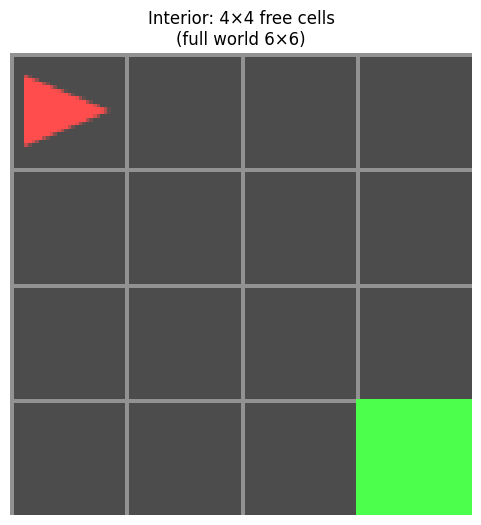


Training EME agent on 4×4 interior...
Episode 10/200 | Avg Reward: 0.00 | Avg Steps: 70.20 | Avg Bonus: 0.0172 | Success Rate: 0.50 | Epsilon: 0.9044
  Components: Reward Diff: 0.0039 | Spatial: 0.2107 | Policy: 0.0184 | Variance: 0.5149
Episode 20/200 | Avg Reward: 1.00 | Avg Steps: 45.90 | Avg Bonus: 0.0088 | Success Rate: 1.00 | Epsilon: 0.8179
  Components: Reward Diff: 0.0280 | Spatial: 0.2633 | Policy: 0.1909 | Variance: 0.0001
Episode 30/200 | Avg Reward: 0.60 | Avg Steps: 58.50 | Avg Bonus: 0.0067 | Success Rate: 0.80 | Epsilon: 0.7397
  Components: Reward Diff: 0.0274 | Spatial: 0.2491 | Policy: 0.2107 | Variance: 0.0001
Episode 40/200 | Avg Reward: 1.00 | Avg Steps: 34.50 | Avg Bonus: 0.0057 | Success Rate: 1.00 | Epsilon: 0.6690
  Components: Reward Diff: 0.0403 | Spatial: 0.2936 | Policy: 0.2917 | Variance: 0.0001
Episode 50/200 | Avg Reward: 1.00 | Avg Steps: 33.50 | Avg Bonus: 0.0073 | Success Rate: 1.00 | Epsilon: 0.6050
  Components: Reward Diff: 0.0626 | Spatial: 0.38

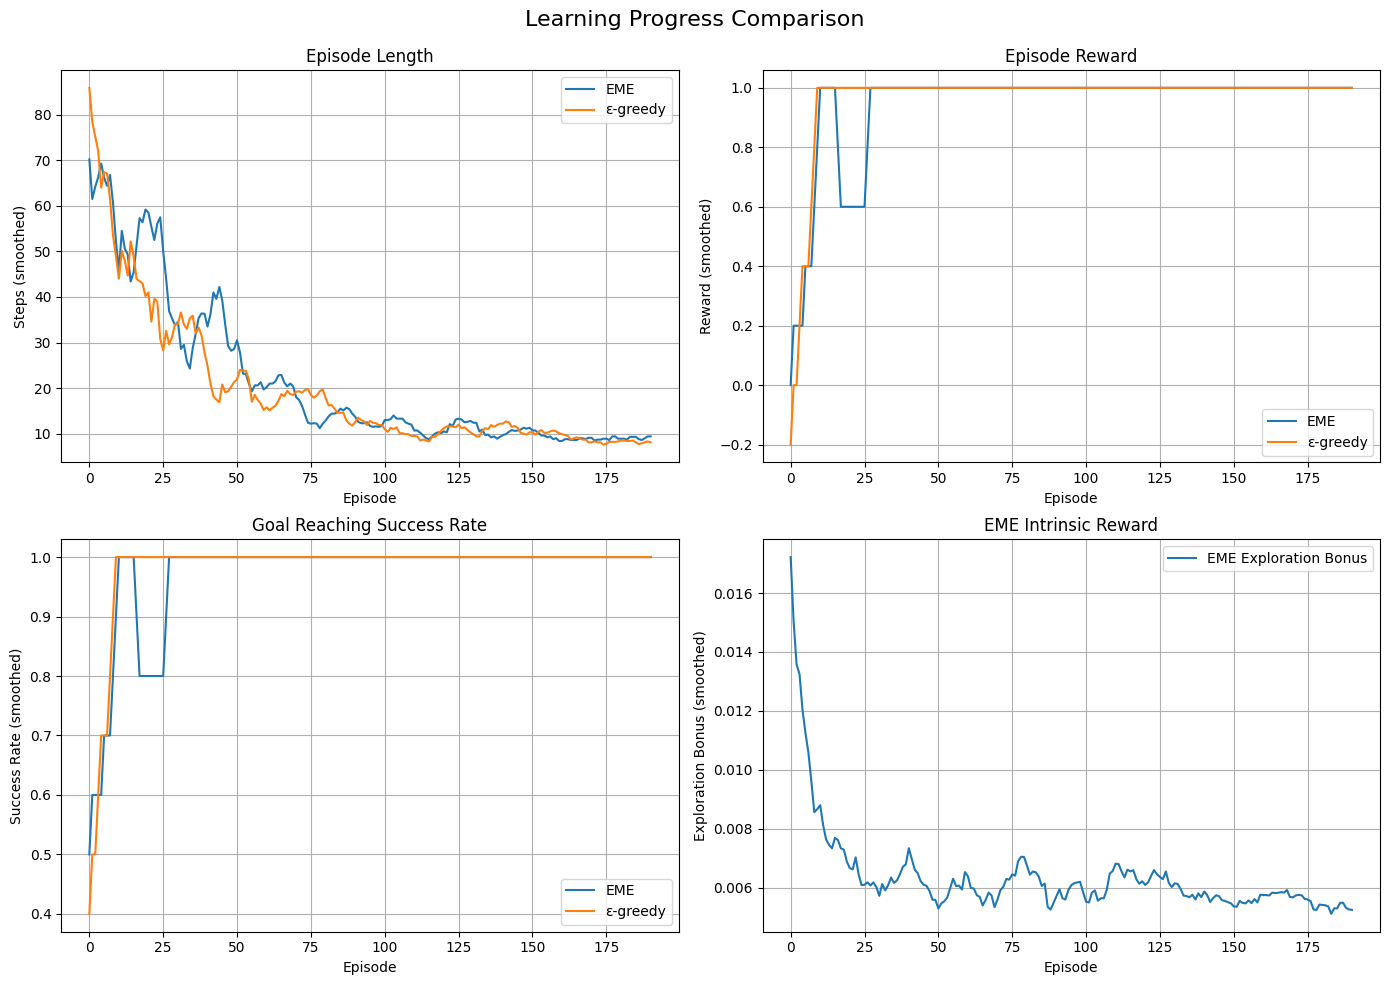


Trajectory (EME):


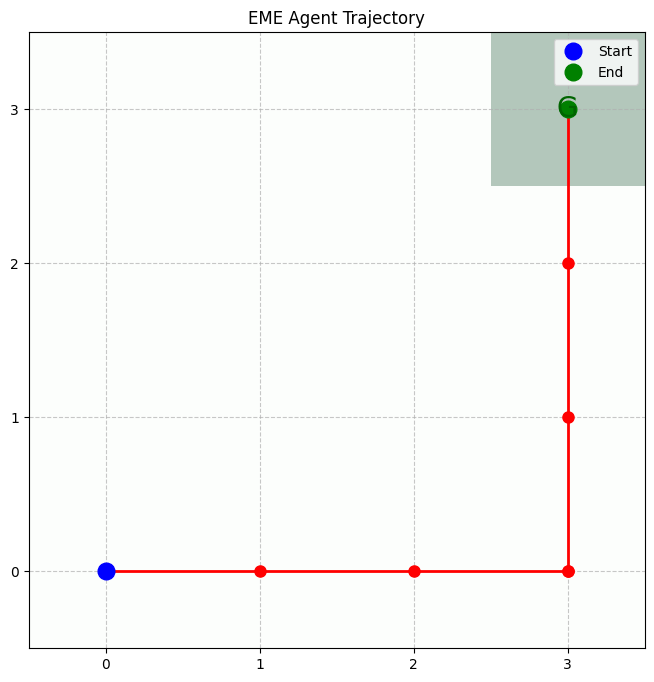


Trajectory (ε-greedy):


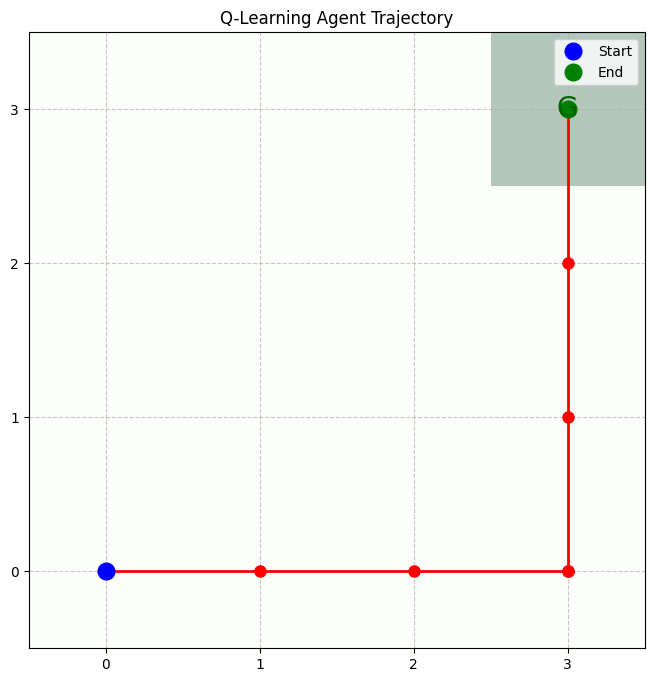


Performance Summary (last 20 episodes):
 EME   Success Rate: 1.0000
 ε-greedy Success Rate: 1.0000
 EME   Avg Steps:      9.15
 ε-greedy Avg Steps:      8.30
 EME   Avg Reward:     1.00
 ε-greedy Avg Reward:     1.00


In [28]:
print("RUNNING BASIC COMPARISON")
eme_agent, q_agent, eme_results, q_results = run_exploration_comparison(
        grid_size=4,
        num_episodes=200
    )


 EXPERIMENTING WITH ENSEMBLE SIZES 

Training EME agent with ensemble size 1...
Episode 10/100 | Avg Reward: 0.40 | Avg Steps: 62.10 | Avg Bonus: 0.0225 | Success Rate: 0.70 | Epsilon: 0.9044
  Components: Reward Diff: 0.0093 | Spatial: 0.2155 | Policy: 0.0380 | Variance: 0.4480
Episode 20/100 | Avg Reward: 0.80 | Avg Steps: 54.00 | Avg Bonus: 0.0103 | Success Rate: 0.90 | Epsilon: 0.8179
  Components: Reward Diff: 0.0288 | Spatial: 0.2646 | Policy: 0.1967 | Variance: 0.0249
Episode 30/100 | Avg Reward: 1.00 | Avg Steps: 42.50 | Avg Bonus: 0.0081 | Success Rate: 1.00 | Epsilon: 0.7397
  Components: Reward Diff: 0.0278 | Spatial: 0.3164 | Policy: 0.1632 | Variance: 0.0000
Episode 40/100 | Avg Reward: 1.00 | Avg Steps: 48.90 | Avg Bonus: 0.0072 | Success Rate: 1.00 | Epsilon: 0.6690
  Components: Reward Diff: 0.0542 | Spatial: 0.3505 | Policy: 0.4870 | Variance: 0.0000
Episode 50/100 | Avg Reward: 1.00 | Avg Steps: 27.00 | Avg Bonus: 0.0075 | Success Rate: 1.00 | Epsilon: 0.6050
  Compo

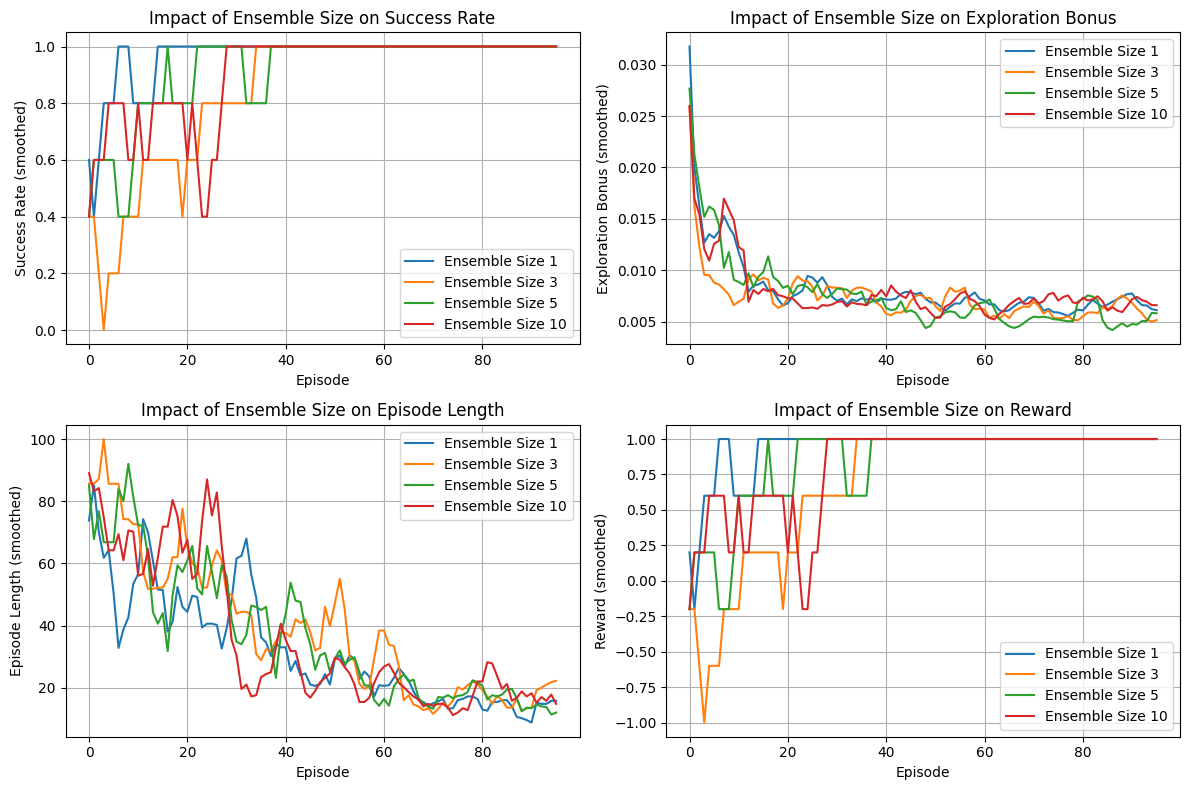


Final Performance with Different Ensemble Sizes:
Ensemble Size 1: Success Rate = 1.0000, Avg Steps = 13.40
Ensemble Size 3: Success Rate = 1.0000, Avg Steps = 17.15
Ensemble Size 5: Success Rate = 1.0000, Avg Steps = 16.35
Ensemble Size 10: Success Rate = 1.0000, Avg Steps = 19.05


In [29]:
# Run the ensemble size experiment
print("\n EXPERIMENTING WITH ENSEMBLE SIZES ")
ensemble_results = experiment_with_ensemble_sizes(grid_size=4, max_episodes=100)


RUNNING INCREASED DIFFICULTY EXPERIMENTS 


Running experiment with grid size 4 


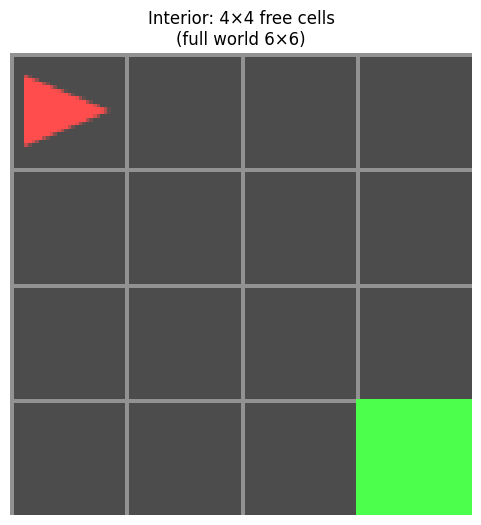


Training EME agent on 4×4 interior...
Episode 10/400 | Avg Reward: 0.00 | Avg Steps: 70.20 | Avg Bonus: 0.0172 | Success Rate: 0.50 | Epsilon: 0.9044
  Components: Reward Diff: 0.0039 | Spatial: 0.2107 | Policy: 0.0184 | Variance: 0.5149
Episode 20/400 | Avg Reward: 1.00 | Avg Steps: 45.90 | Avg Bonus: 0.0088 | Success Rate: 1.00 | Epsilon: 0.8179
  Components: Reward Diff: 0.0280 | Spatial: 0.2633 | Policy: 0.1909 | Variance: 0.0001
Episode 30/400 | Avg Reward: 0.60 | Avg Steps: 58.50 | Avg Bonus: 0.0067 | Success Rate: 0.80 | Epsilon: 0.7397
  Components: Reward Diff: 0.0274 | Spatial: 0.2491 | Policy: 0.2107 | Variance: 0.0001
Episode 40/400 | Avg Reward: 1.00 | Avg Steps: 34.50 | Avg Bonus: 0.0057 | Success Rate: 1.00 | Epsilon: 0.6690
  Components: Reward Diff: 0.0403 | Spatial: 0.2936 | Policy: 0.2917 | Variance: 0.0001
Episode 50/400 | Avg Reward: 1.00 | Avg Steps: 33.50 | Avg Bonus: 0.0073 | Success Rate: 1.00 | Epsilon: 0.6050
  Components: Reward Diff: 0.0626 | Spatial: 0.38

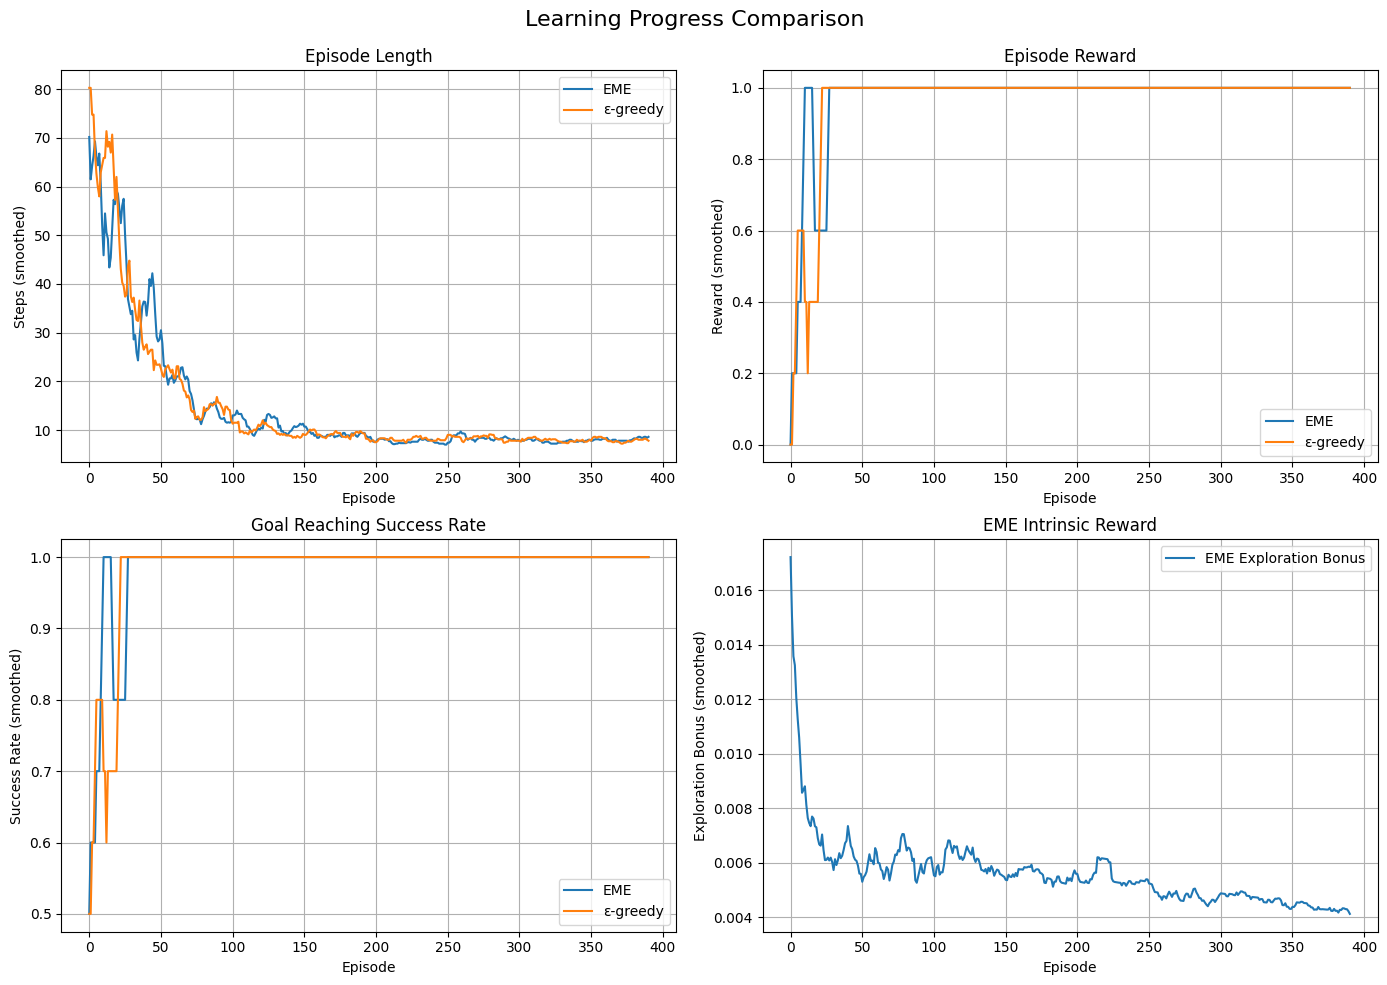


Trajectory (EME):


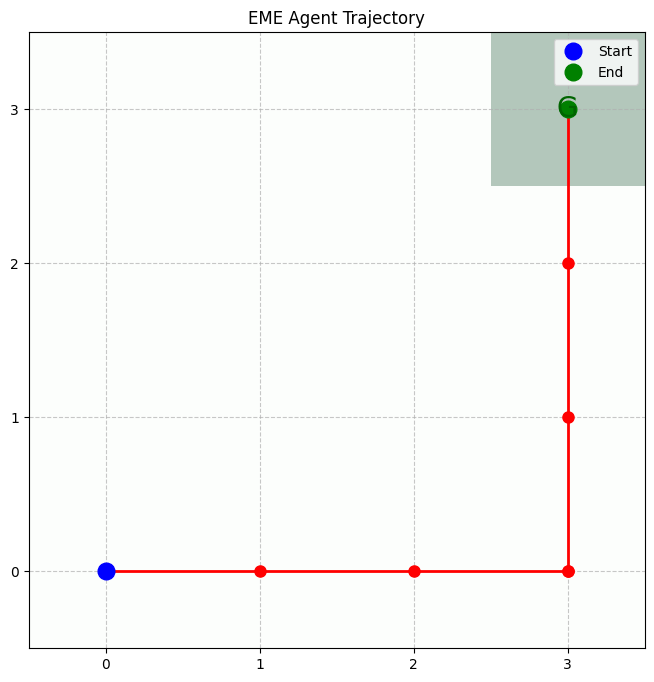


Trajectory (ε-greedy):


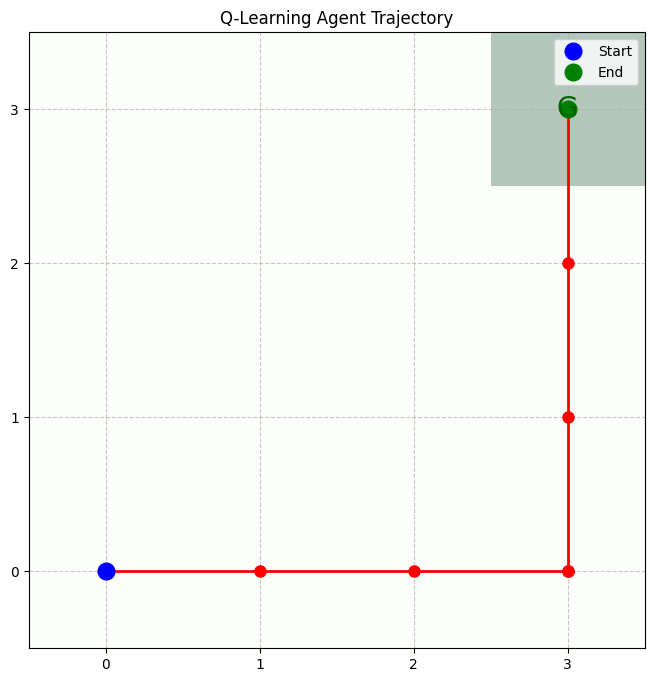


Performance Summary (last 20 episodes):
 EME   Success Rate: 1.0000
 ε-greedy Success Rate: 1.0000
 EME   Avg Steps:      8.45
 ε-greedy Avg Steps:      7.90
 EME   Avg Reward:     1.00
 ε-greedy Avg Reward:     1.00


Running experiment with grid size 6 


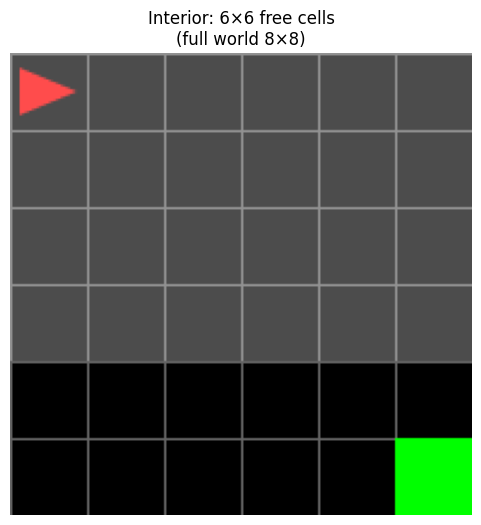


Training EME agent on 6×6 interior...
Episode 10/600 | Avg Reward: -0.60 | Avg Steps: 94.00 | Avg Bonus: 0.0308 | Success Rate: 0.20 | Epsilon: 0.9044
  Components: Reward Diff: 0.0017 | Spatial: 0.2527 | Policy: 0.0103 | Variance: 0.7455
Episode 20/600 | Avg Reward: -0.40 | Avg Steps: 84.90 | Avg Bonus: 0.0108 | Success Rate: 0.30 | Epsilon: 0.8179
  Components: Reward Diff: 0.0035 | Spatial: 0.2711 | Policy: 0.0288 | Variance: 0.0229
Episode 30/600 | Avg Reward: -0.80 | Avg Steps: 92.60 | Avg Bonus: 0.0076 | Success Rate: 0.10 | Epsilon: 0.7397
  Components: Reward Diff: 0.0044 | Spatial: 0.2745 | Policy: 0.0375 | Variance: 0.0000
Episode 40/600 | Avg Reward: -0.20 | Avg Steps: 83.50 | Avg Bonus: 0.0090 | Success Rate: 0.40 | Epsilon: 0.6690
  Components: Reward Diff: 0.0068 | Spatial: 0.3398 | Policy: 0.0485 | Variance: 0.0050
Episode 50/600 | Avg Reward: 0.20 | Avg Steps: 67.40 | Avg Bonus: 0.0077 | Success Rate: 0.60 | Epsilon: 0.6050
  Components: Reward Diff: 0.0144 | Spatial: 

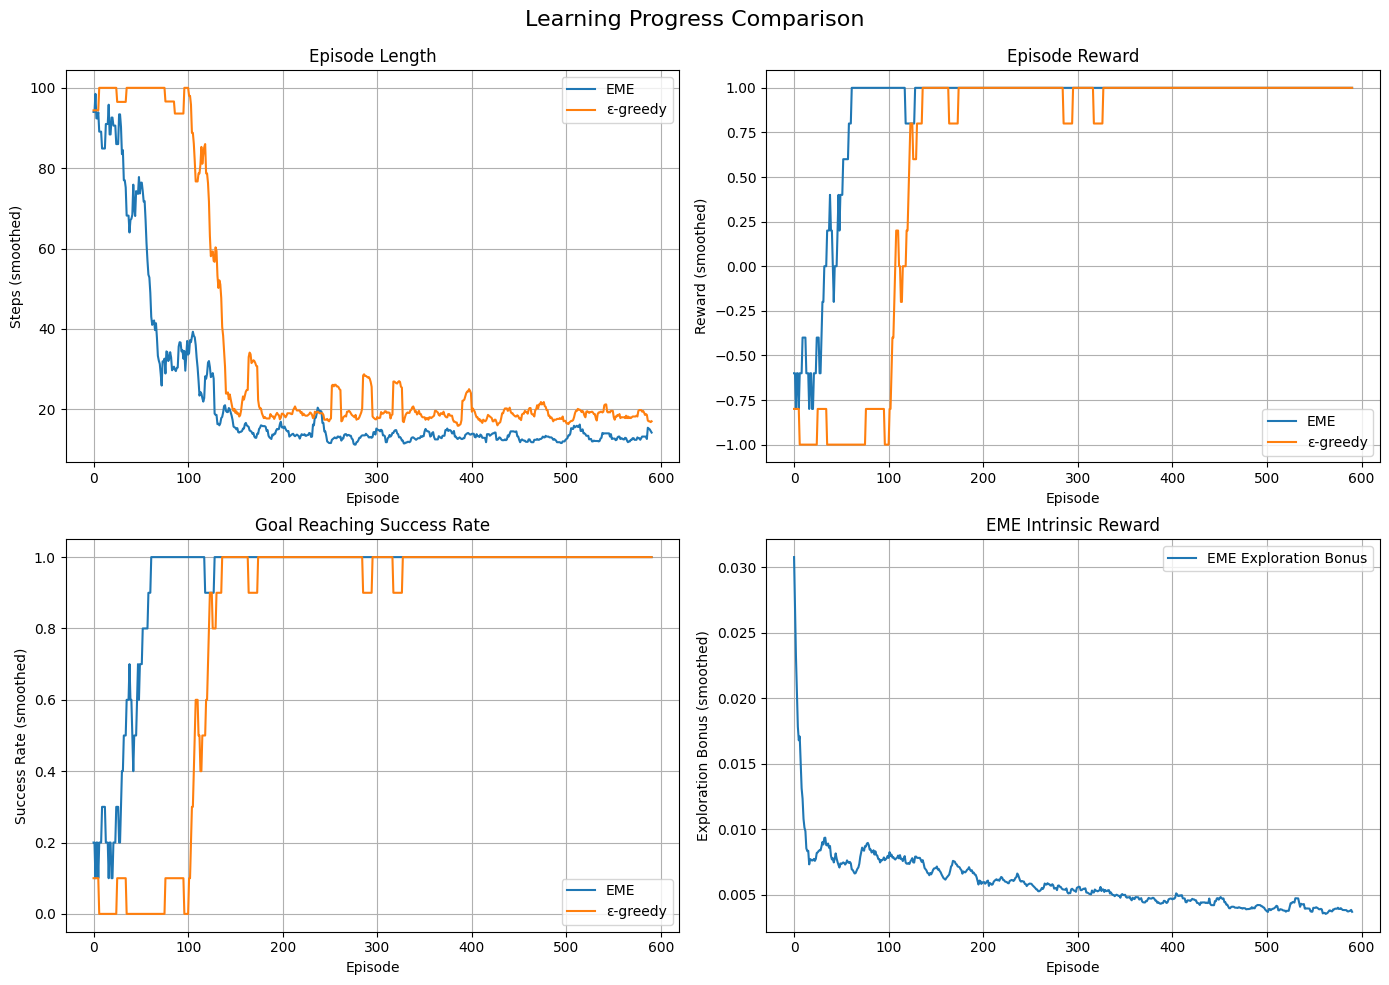


Trajectory (EME):


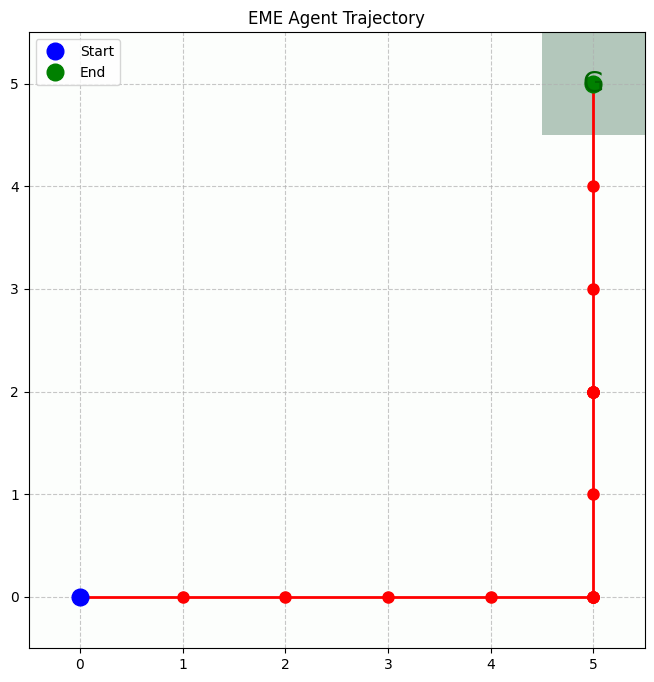


Trajectory (ε-greedy):


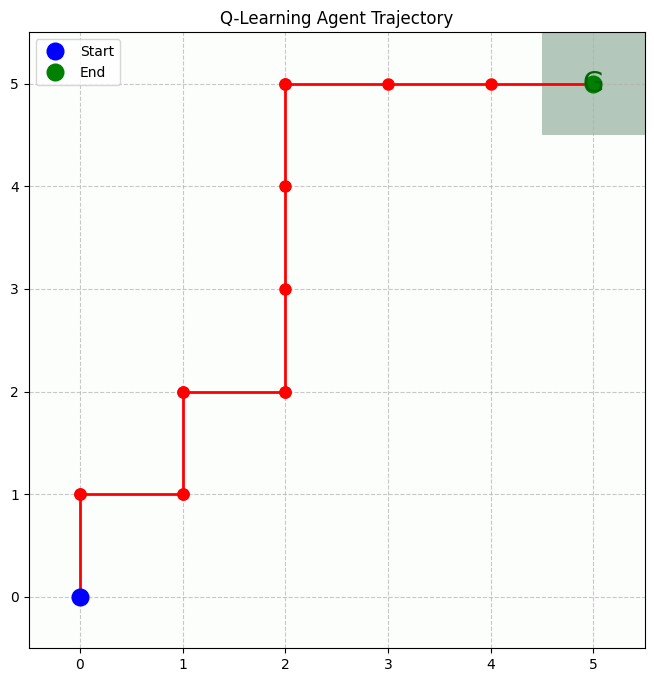


Performance Summary (last 20 episodes):
 EME   Success Rate: 1.0000
 ε-greedy Success Rate: 1.0000
 EME   Avg Steps:      13.70
 ε-greedy Avg Steps:      18.20
 EME   Avg Reward:     1.00
 ε-greedy Avg Reward:     1.00


Running experiment with grid size 8 


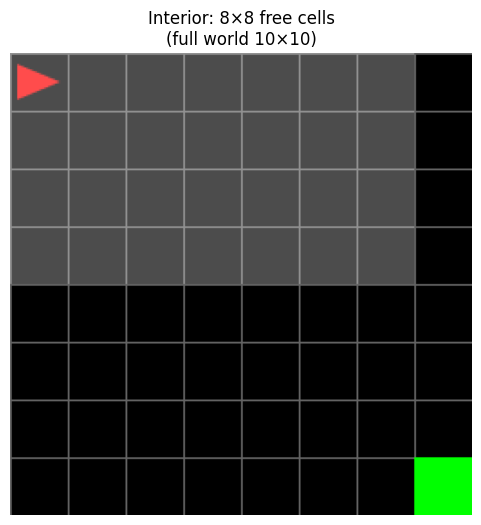


Training EME agent on 8×8 interior...
Episode 10/800 | Avg Reward: -1.00 | Avg Steps: 100.00 | Avg Bonus: 0.0341 | Success Rate: 0.00 | Epsilon: 0.9044
  Components: Reward Diff: 0.0016 | Spatial: 0.2700 | Policy: 0.0105 | Variance: 0.8450
Episode 20/800 | Avg Reward: -0.40 | Avg Steps: 92.50 | Avg Bonus: 0.0176 | Success Rate: 0.30 | Epsilon: 0.8179
  Components: Reward Diff: 0.0021 | Spatial: 0.2994 | Policy: 0.0188 | Variance: 0.1956
Episode 30/800 | Avg Reward: -0.60 | Avg Steps: 95.80 | Avg Bonus: 0.0132 | Success Rate: 0.20 | Epsilon: 0.7397
  Components: Reward Diff: 0.0028 | Spatial: 0.2792 | Policy: 0.0303 | Variance: 0.1450
Episode 40/800 | Avg Reward: -0.60 | Avg Steps: 98.00 | Avg Bonus: 0.0112 | Success Rate: 0.20 | Epsilon: 0.6690
  Components: Reward Diff: 0.0043 | Spatial: 0.3420 | Policy: 0.0417 | Variance: 0.0558
Episode 50/800 | Avg Reward: -0.40 | Avg Steps: 90.80 | Avg Bonus: 0.0090 | Success Rate: 0.30 | Epsilon: 0.6050
  Components: Reward Diff: 0.0044 | Spatial

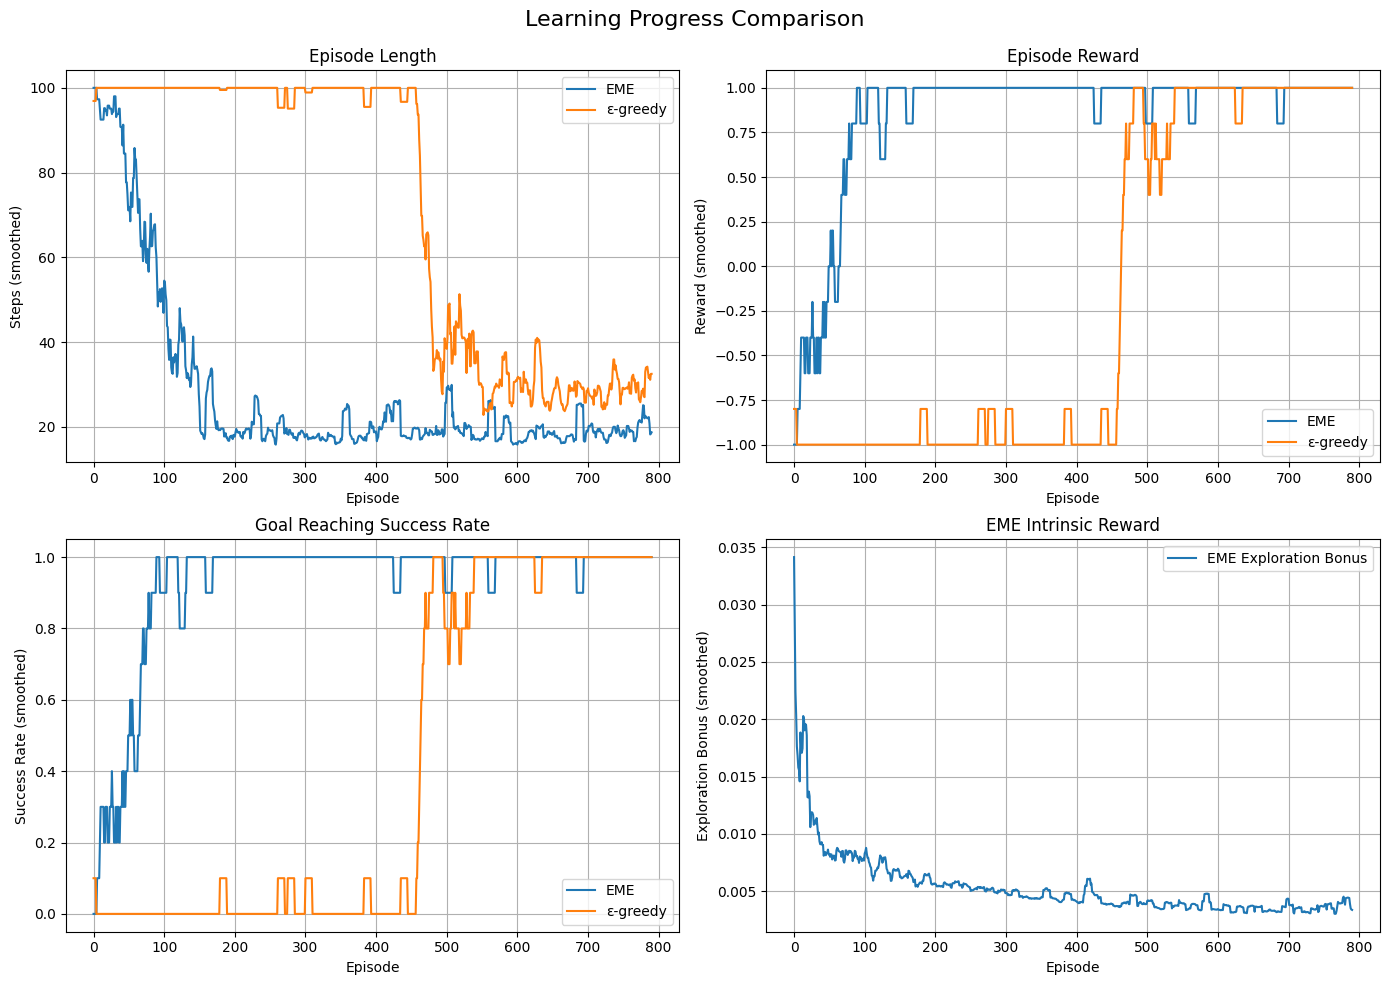


Trajectory (EME):


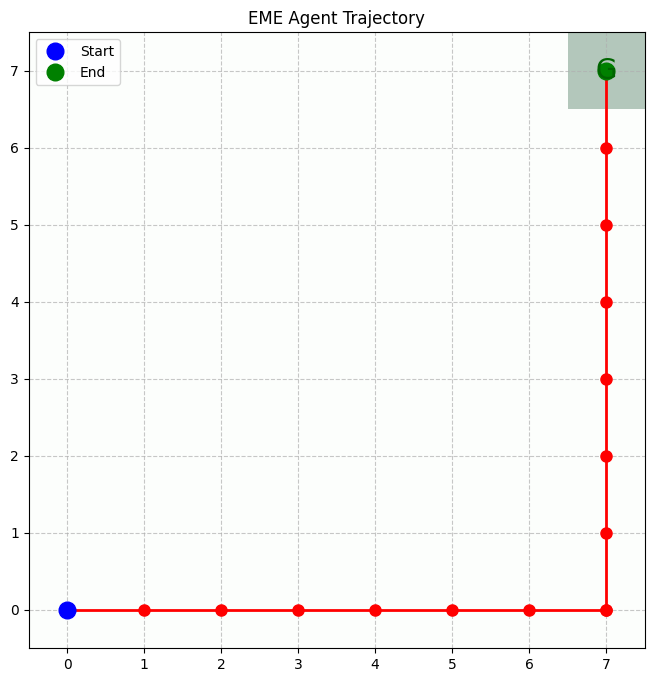


Trajectory (ε-greedy):


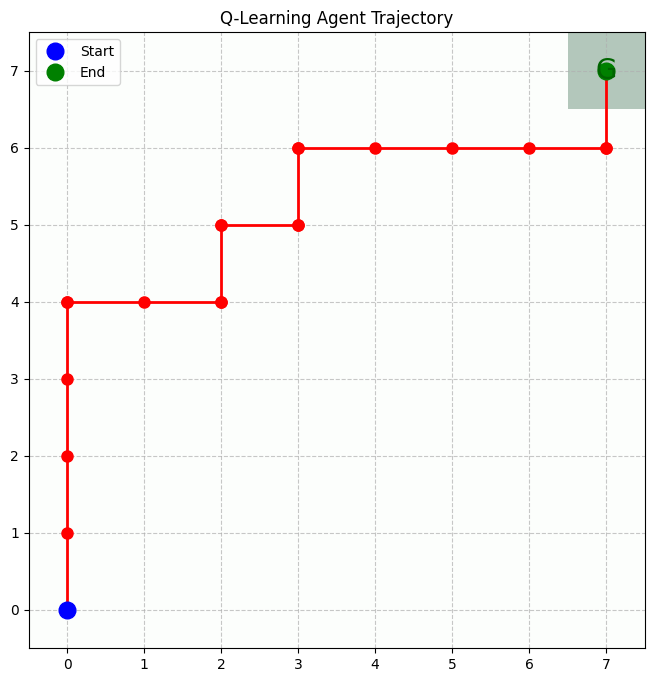


Performance Summary (last 20 episodes):
 EME   Success Rate: 1.0000
 ε-greedy Success Rate: 1.0000
 EME   Avg Steps:      20.35
 ε-greedy Avg Steps:      29.75
 EME   Avg Reward:     1.00
 ε-greedy Avg Reward:     1.00


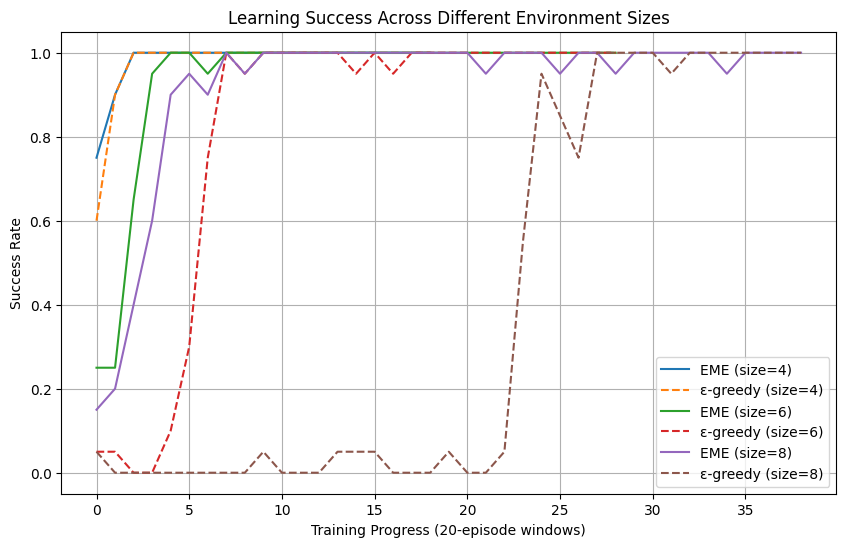


Performance Summary Table (Last 20 Episodes):


,Grid Size,EME Success Rate,ε-greedy Success Rate,EME Avg Steps,ε-greedy Avg Steps,EME Avg Reward,ε-greedy Avg Reward
0,4x4,1.0,1.0,8.45,7.90,1.0,1.0
1,6x6,1.0,1.0,13.70,18.20,1.0,1.0
2,8x8,1.0,1.0,20.35,29.75,1.0,1.0


In [34]:

print("\nRUNNING INCREASED DIFFICULTY EXPERIMENTS ")
difficulty_results = run_increased_difficulty_experiments()